# Group 9
## ME3101 PROJECT

In [7]:
# --- 1. Imports
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torch, torch.nn as nn, torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path


Classes found: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']


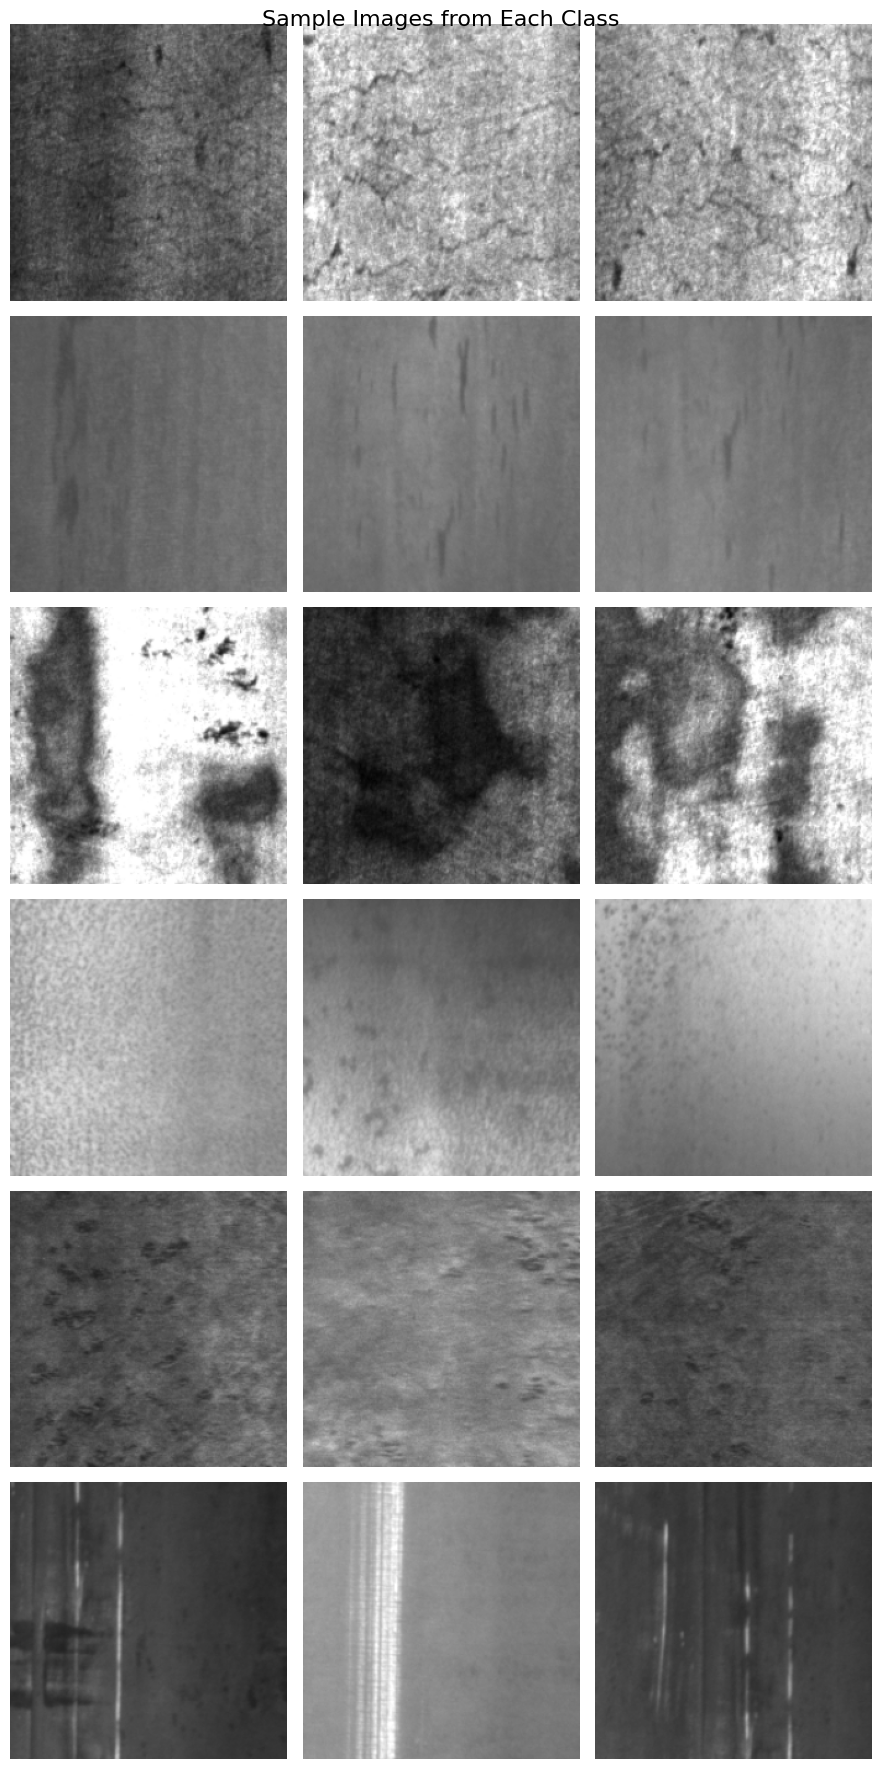

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import random
from torchvision import transforms, datasets
from pathlib import Path

# Path to training data
train_dir = Path("/content/Metal_Surface_Defects_Data/Metal Surface Defects Data/train")

# Simple transform for visualization (no normalization)
transform_vis = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load dataset
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_vis)
classes = train_dataset.classes
print("Classes found:", classes)

# Function to unnormalize tensor for display
def imshow(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.axis('off')

# Function to show few samples per class
def visualize_samples(dataset, classes, n=3):
    plt.figure(figsize=(n*3, len(classes)*3))
    for i, cls in enumerate(classes):
        # Indices for that class
        indices = [idx for idx, (_, label) in enumerate(dataset) if label == i]
        sample_indices = random.sample(indices, min(n, len(indices)))

        for j, idx in enumerate(sample_indices):
            img, label = dataset[idx]
            plt.subplot(len(classes), n, i*n + j + 1)
            imshow(img)
            if j == 0:
                plt.ylabel(cls, fontsize=12)
    plt.suptitle("Sample Images from Each Class", fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize samples
visualize_samples(train_dataset, classes, n=3)


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """A basic residual block with two convolution layers and a skip connection"""
    def __init__(self, in_channels, out_channels, stride=1, dropout_rate=0.3):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(dropout_rate)

        # Shortcut (1x1 conv to match dimensions if needed)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class SimpleResidualCNN(nn.Module):
    def __init__(self, num_classes=6, dropout_rate=0.3):
        super(SimpleResidualCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.resblock1 = ResidualBlock(32, 32, dropout_rate=dropout_rate)
        self.resblock2 = ResidualBlock(32, 64, stride=2, dropout_rate=dropout_rate)
        self.resblock3 = ResidualBlock(64, 128, stride=2, dropout_rate=dropout_rate)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [ ]:
model = SimpleResidualCNN(num_classes=len(train_data.classes)).to(device)



🔍 Testing configuration: lr=0.001, dropout=0.3
Epoch 1/10 | Train Loss: 0.9498 | Train Acc: 63.16% | Val Loss: 1.1394 | Val Acc: 54.17%
Epoch 2/10 | Train Loss: 0.6630 | Train Acc: 74.40% | Val Loss: 0.7255 | Val Acc: 72.22%
Epoch 3/10 | Train Loss: 0.6001 | Train Acc: 76.93% | Val Loss: 0.5381 | Val Acc: 80.56%
Epoch 4/10 | Train Loss: 0.5025 | Train Acc: 81.28% | Val Loss: 0.4262 | Val Acc: 86.11%
Epoch 5/10 | Train Loss: 0.5161 | Train Acc: 80.19% | Val Loss: 0.3125 | Val Acc: 83.33%
Epoch 6/10 | Train Loss: 0.5051 | Train Acc: 81.28% | Val Loss: 0.2870 | Val Acc: 91.67%
Epoch 7/10 | Train Loss: 0.3963 | Train Acc: 86.41% | Val Loss: 0.1774 | Val Acc: 91.67%
Epoch 8/10 | Train Loss: 0.3708 | Train Acc: 88.04% | Val Loss: 0.1313 | Val Acc: 94.44%
Epoch 9/10 | Train Loss: 0.3532 | Train Acc: 88.29% | Val Loss: 0.1446 | Val Acc: 95.83%
Epoch 10/10 | Train Loss: 0.3468 | Train Acc: 87.68% | Val Loss: 0.2113 | Val Acc: 91.67%

🔍 Testing configuration: lr=0.001, dropout=0.4
Epoch 1/10 | 

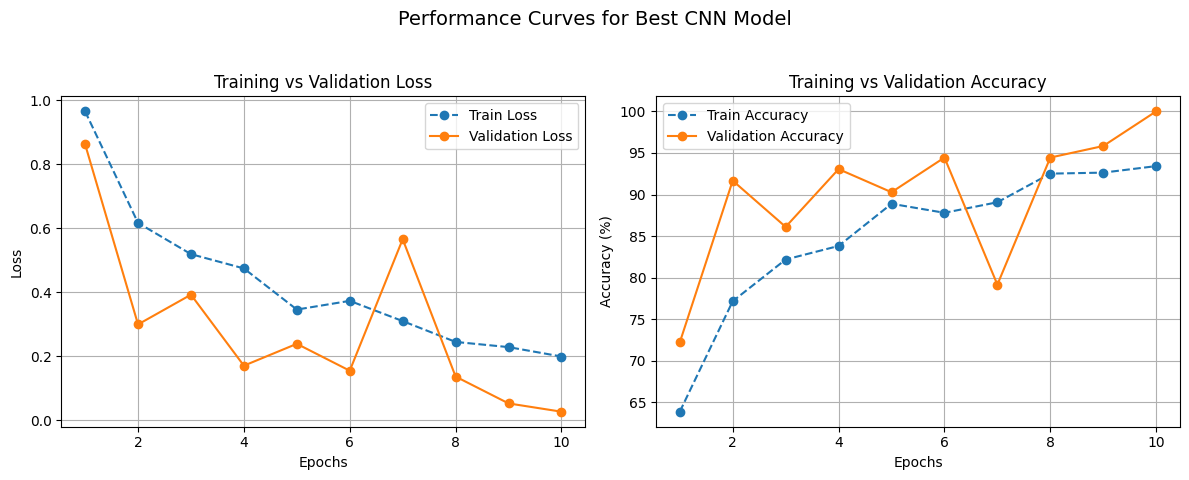


🎯 Final Test Accuracy: 94.44%

📄 Classification Report:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       0.91      0.83      0.87        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72



<Figure size 800x600 with 0 Axes>

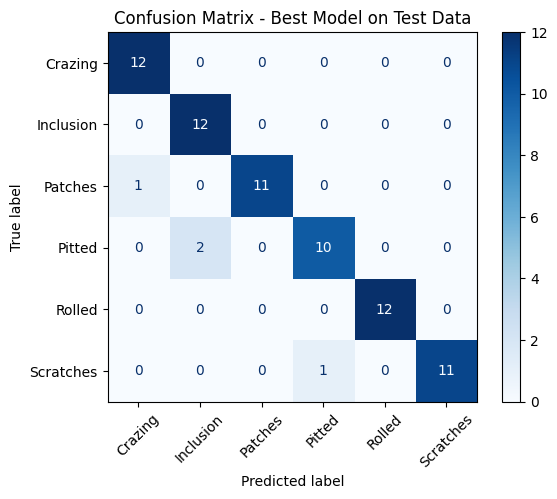

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================================
# 1️⃣ TRANSFORMS AND DATASET
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

base_path = "/content/Metal_Surface_Defects_Data/Metal Surface Defects Data/"

train_data = datasets.ImageFolder(root=base_path + "train", transform=transform)
val_data = datasets.ImageFolder(root=base_path + "valid", transform=transform)
test_data = datasets.ImageFolder(root=base_path + "test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# 2️⃣ TRAINING FUNCTION (records accuracy/loss)
# ==========================================================
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    best_val_acc = 0.0
    best_model_wts = model.state_dict().copy()

    # Tracking metrics
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Record
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()

    model.load_state_dict(best_model_wts)
    return model, best_val_acc, (train_losses, val_losses, train_accs, val_accs)

# ==========================================================
# 3️⃣ HYPERPARAMETER TUNING
# ==========================================================
learning_rates = [0.001, 0.0005]
dropouts = [0.3, 0.4]
best_overall_acc = 0
best_config = None
best_model = None
best_metrics = None

for lr in learning_rates:
    for dp in dropouts:
        print(f"\n🔍 Testing configuration: lr={lr}, dropout={dp}")
        model = SimpleResidualCNN(num_classes=len(train_data.classes), dropout_rate=dp).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        trained_model, val_acc, metrics = train_and_validate(model, train_loader, val_loader, criterion, optimizer, epochs=10)

        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            best_model = trained_model
            best_config = (lr, dp)
            best_metrics = metrics

print(f"\n✅ Best Configuration Found -> Learning Rate: {best_config[0]}, Dropout: {best_config[1]} | Validation Accuracy: {best_overall_acc:.2f}%")

# ==========================================================
# 4️⃣ TRAINING CURVES FOR BEST MODEL
# ==========================================================
train_losses, val_losses, train_accs, val_accs = best_metrics

epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o--', label='Train Loss')
plt.plot(epochs, val_losses, 'o-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'o--', label='Train Accuracy')
plt.plot(epochs, val_accs, 'o-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle("Performance Curves for Best CNN Model", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================================
# 5️⃣ TEST SET EVALUATION + CONFUSION MATRIX
# ==========================================================
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")
print("\n📄 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.classes)
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Best Model on Test Data")
plt.show()


# END
